<a href="https://colab.research.google.com/github/hankii3/ML300/blob/main/Chapter_1_%E1%84%8C%E1%85%A1%E1%84%83%E1%85%A9%E1%86%BC%E1%84%8B%E1%85%B3%E1%84%85%E1%85%A9_%E1%84%86%E1%85%A9%E1%84%8B%E1%85%B3%E1%86%AB_%E1%84%83%E1%85%A6%E1%84%8B%E1%85%B5%E1%84%90%E1%85%A5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 주제 : 자동으로 모은 데이터는 분석하기 어렵다면서? 자동으로 모은 중고 자동차 데이터를 분석해보자!
----------

## 실습 가이드
    1. 데이터를 다운로드하여 Colab에 불러옵니다.
    2. 필요한 라이브러리는 모두 코드로 작성되어 있습니다.
    3. 코드는 위에서부터 아래로 순서대로 실행합니다.
    
    
## 데이터 소개
    - 이번 주제는 Used Cars Dataset을 사용합니다.
    - 파일은 한 개이며, 각각의 컬럼은 아래와 같습니다.
    
    - vehicles.csv
    id : 중고차 거래의 아이디
    url : 중고차 거래 페이지
    region : 해당 거래의 관리 지점
    region_url : 거래 관리 지점의 홈페이지
    price : 기입된 자동차의 거래가
    year : 거래가 기입된 년도
    manufacturer : 자동차를 생산한 회사
    model : 자동차 모델명
    condition : 자동차의 상태
    cylinders : 자동차의 기통 수
    fuel : 자동차의 연료 타입
    odometer : 자동차의 운행 마일 수
    title_status : 자동차의 타이틀 상태 (소유주 등록 상태)
    transmission : 자동차의 트랜스미션 종류
    vin : 자동차의 식별 번호 (vehicle identification number)
    drive : 자동차의 구동 타입
    size : 자동차 크기
    type : 자동차의 일반 타입 (세단, ...)
    paint_color : 자동차 색상
    image_url : 자동차 이미지
    description : 세부 설명
    county : 실수로 생성된 미사용 컬럼
    state : 거래가 업로드된 미 주
    lat : 거래가 업로드된 곳의 위도
    long : 거래가 업로드된 곳의 경도
    
    
- 데이터 출처: https://www.kaggle.com/austinreese/craigslist-carstrucks-data

## 최종 목표
    - 스크래핑된 dirty 데이터 클리닝 방법 이해
    - 다양한 종류의 데이터 정규화 방법 습득
    - 데이터 시각화를 통한 인사이트 습득 방법의 이해
    - Scikit-learn 기반의 모델 학습 방법 습득
    - XGBoost, LightGBM 기반의 모델 학습 방법 습득
    - 학습된 모델의 평가 방법 및 시각화 방법 습득

- 출제자 : 신제용 강사
---

## Step 0. 데이터 스크래핑이 대하여

### 스크래핑을 이용한 자동 데이터 습득

### 스크래핑된 데이터에서 아웃라이어의 특징


## Step 1. 데이터셋 준비하기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 문제 1. Colab Notebook에 Kaggle API 세팅하기


In [ ]:
import os

In [ ]:
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기
os.environ[ 'KAGGLE_USERNAME' ] = 'kimhanki'
os.environ[ 'KAGGLE_KEY' ] = 'b0959877b560f24c621ebdd0b822a1b5'


### 문제 2. 데이터 다운로드 및 압축 해제하기


In [ ]:
# Linux 명령어로 Kaggle API를 이용하여 데이터셋 다운로드하기 (!kaggle ~)
# Linux 명령어로 압축 해제하기

!rm *.*
!kaggle datasets download -d austinreese/craigslist-carstrucks-data
!unzip '*.zip'


rm: cannot remove '*.*': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data
License(s): CC0-1.0
100% 262M/262M [00:02<00:00, 96.2MB/s]

Archive:  craigslist-carstrucks-data.zip
  inflating: vehicles.csv            


### 문제 3. Pandas 라이브러리로 csv파일 읽어들이기


In [ ]:
df = pd.read_csv('vehicles.csv')

## Step 2. EDA 및 데이터 기초 통계 분석


### 문제 4. 불필요한 데이터 데이터프레임에서 제거하기


In [ ]:
# DataFrame에서 제공하는 메소드를 이용하여 각 데이터프레임의 구조 분석하기 (head(), info(), describe())
# 데이터프레임에서 불필요한 컬럼 제거하기
df.head()



,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [ ]:
df.isna().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678


In [ ]:
df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [ ]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [ ]:
df.drop(['id', 'url', 'region_url', 'VIN',
       'image_url', 'description', 'state', 'lat', 'long',
       'posting_date'], axis = 1, inplace = True)

KeyError: "['id', 'url', 'region_url', 'VIN', 'image_url', 'description', 'state', 'lat', 'long', 'posting_date'] not found in axis"

In [ ]:
df.drop('county', axis = 1, inplace = True)

In [ ]:
df['age'] = 2026 - df['year']
df.drop('year',axis = 1, inplace = True)

In [ ]:
df

,region,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,county,age
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,23590,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,NaN,sedan,NaN,NaN,7.0
426876,wyoming,30590,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,fwd,NaN,sedan,red,NaN,6.0
426877,wyoming,34990,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,NaN,NaN,hatchback,white,NaN,6.0
426878,wyoming,28990,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,NaN,sedan,silver,NaN,8.0


### 문제 5. 범주형 데이터의 통계 분석하기


In [ ]:
df.columns

Index(['region', 'price', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size',
       'type', 'paint_color', 'county', 'age'],
      dtype='object')

In [ ]:
df['manufacturer'].value_counts()

,count
manufacturer,
ford,70985
chevrolet,55064
toyota,34202
honda,21269
nissan,19067
jeep,19014
ram,18342
gmc,16785
bmw,14699


<Axes: xlabel='count', ylabel='manufacturer'>

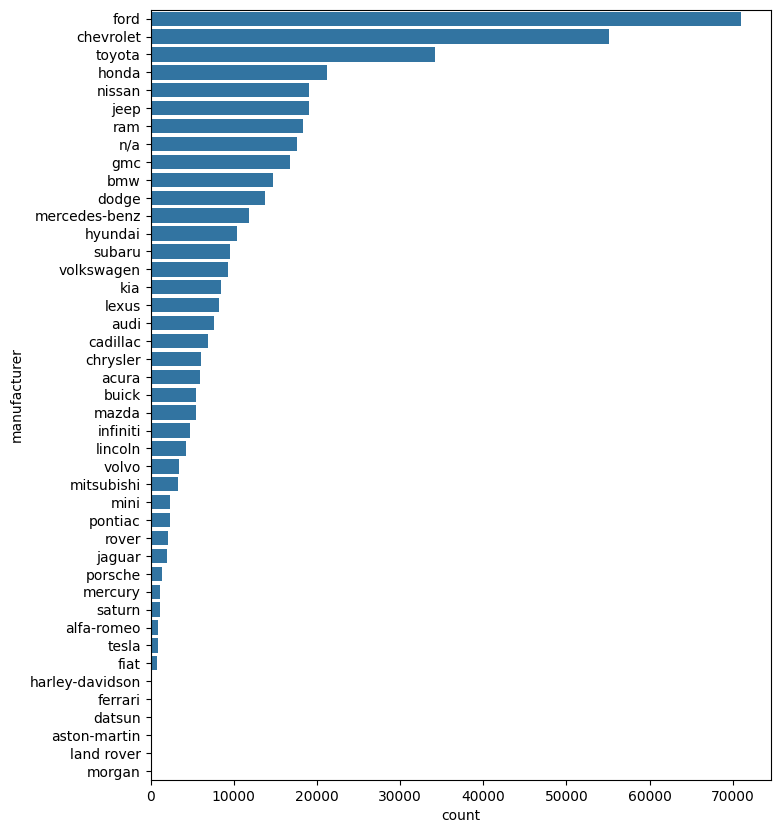

In [ ]:
fig = plt.figure(figsize = (8,10))
sns.countplot(y = 'manufacturer', data = df.fillna('n/a'), order = df.fillna('n/a')['manufacturer'].value_counts().index)

In [ ]:
len(df['model'].value_counts())

29667

In [ ]:
for model, num in zip(df['model'].value_counts().index, df['model'].value_counts()):
  print(model, num)

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Bentley MK VI saloon 1
s10 ext. cab 1
Model  LS    Silverado Z71 1
sonata gls v6 1
optimia premium 1
es350 luxury package 1
Accura MDX Technology 1
tahoe -lt 1
golf r dcc & nav 1
camaro 2dr cpe ss w/2 1
velar d1 1
tucson awd 4dr gls *90 d 1
civic touring cvt 1
a6 4dr sdn quattro 3.0t pr 1
td6 dies 1
q7 3.0 tfsi premium plus 1
escalade platinum edit 1
tlx 4dr sdn fwd v6 advanc 1
terrain 4dr slt w/slt-1 1
golf gti se 1
transit t350 stakebed truck 1
transit connect xl van 1
glc glc 300 4mati 1
nx 300h base 1
camry le auto 1
cts 4dr sdn 2.0l turbo 1
c-class c 63 amg® 1
f-150 xl 3dr extended cab 1
x3 xdrive28i sports activit 1
soul ev 5dr wgn + 1
3500 cummins laramie 1
f-450 super duty king ranch 1
mdx fwd 4dr w/advance 1
rx 350 4dr f sport 1
accord 4dr i4 auto ex-l 1
hardtop 2 door cooper fwd 1
mkc 4dr 1
impreza 2.5i sedan 4d 1
c 300 4matic amg 1
borrego 2wd 4dr v6 ex 1
s3 2.0t quattro prestige 1
caravan passenger 1
kona limited dct 1
equinox 4dr premier

In [ ]:
fig = plt.figure(figsize = (8,10))
sns.countplot(y = 'model', data = df.fillna('n/a'), order = df.fillna('n/a')['model'].value_counts().index)

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7b76f3f15bc0> (for post_execute):


ValueError: 
1500 laramie, $452.02 month, 2.9% apr, $2000 down, 72 m laramie, $452.02 month, 2.9% apr, $2000 down, 72 m
              ^
ParseException: Expected end of text, found '$'  (at char 14), (line:1, col:15)

Error in callback <function flush_figures at 0x7b77081c7100> (for post_execute):


KeyboardInterrupt: 

In [ ]:
fig = plt.figure(figsize = (8,10))
sns.countplot(y = 'condition', data = df.fillna('n/a'), order = df.fillna('n/a')['condition'].value_counts().index)

In [ ]:
fig = plt.figure(figsize = (8,10))
sns.countplot(y = 'cylinders', data = df.fillna('n/a'), order = df.fillna('n/a')['cylinders'].value_counts().index)

In [ ]:
fig = plt.figure(figsize = (8,10))
sns.countplot(y = 'fuel', data = df.fillna('n/a'), order = df.fillna('n/a')['fuel'].value_counts().index)

### 문제 6. 수치형 데이터의 통계 분석하기

In [ ]:
df.columns

In [ ]:
# 수치형 데이터의 값의 범위, 기초 통계 분석하기
sns.boxplot(x='price', data = df)

In [ ]:
sns.histplot(x='odometer', data = df)

In [ ]:
sns.histplot(x='age', data = df, bins = 18)

## Step 3. 데이터 클리닝 수행하기

### 문제 7. 범주형 데이터 시각화하여 분석하기

<Axes: xlabel='manufacturer', ylabel='price'>

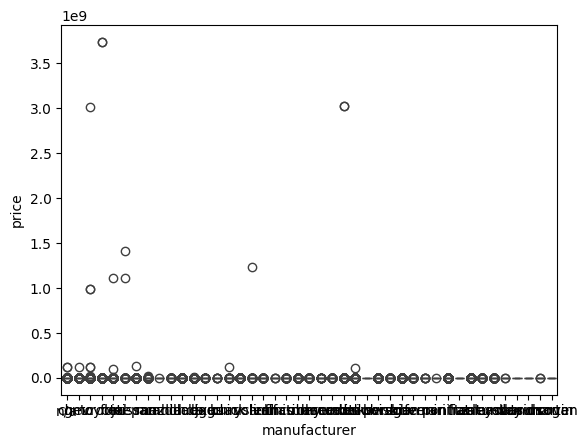

In [ ]:
# Boxplot 계열로 범주형 데이터를 시각화하여 분석하기
sns.boxplot(x = 'manufacturer', y = 'price', data = df.fillna('n/a'))


<Axes: xlabel='fuel', ylabel='price'>

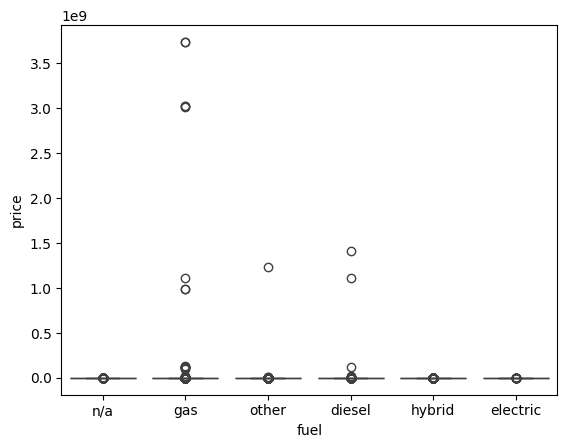

In [ ]:
sns.boxplot(x = 'fuel', y = 'price', data = df.fillna('n/a'))

### 문제 8. 범주형 데이터 클리닝하기

In [ ]:
df.columns

Index(['region', 'price', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size',
       'type', 'paint_color', 'county', 'age'],
      dtype='object')

In [ ]:
# 범주형 데이터를 아래 방법 중 적절히 판단하여 처리하기
# 1. 결손 데이터가 포함된 Row를 제거
# 2. 결손 데이터를 others 범주로 변경하기
# 3. 지나치게 소수로 이루어진 범주를 others 범주로 변경하기

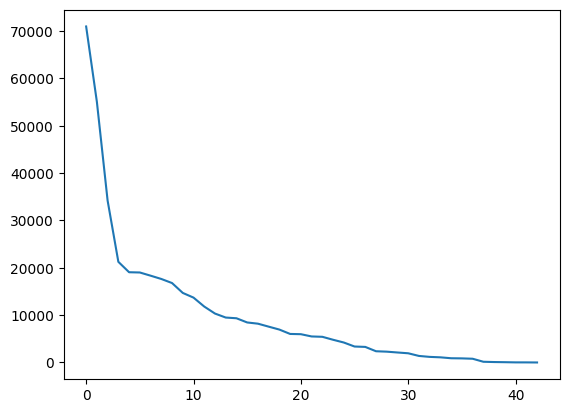

In [ ]:
col = 'manufacturer'
counts = df[col].fillna('others').value_counts()
plt.plot(range(len(counts)), counts)

In [ ]:
n_categorical = 10
df[col] = df[col].apply(lambda s : s if str(s) not in counts.index[n_categorical:] else 'others')

In [ ]:
df[col].value_counts()

,count
manufacturer,
others,139807
ford,70985
chevrolet,55064
toyota,34202
honda,21269
nissan,19067
jeep,19014
ram,18342
gmc,16785


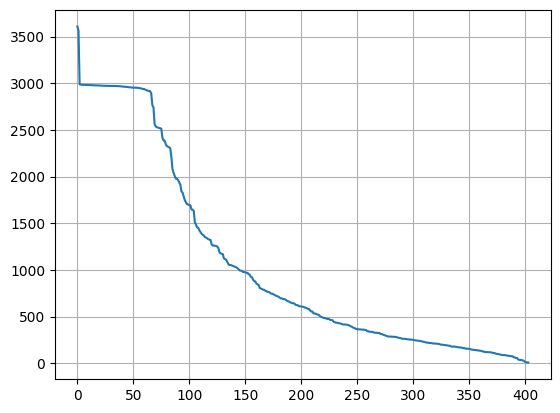

In [ ]:
col = 'region'
counts = df[col].fillna('others').value_counts()
plt.grid()
plt.plot(range(len(counts)), counts)

In [ ]:
n_categorical = 5
df[col] = df[col].apply(lambda s : s if str(s) not in counts.index[n_categorical:] else 'others')
df[col].value_counts()

,count
region,
others,410754
columbus,3608
jacksonville,3562
spokane / coeur d'alene,2988
eugene,2985
fresno / madera,2983


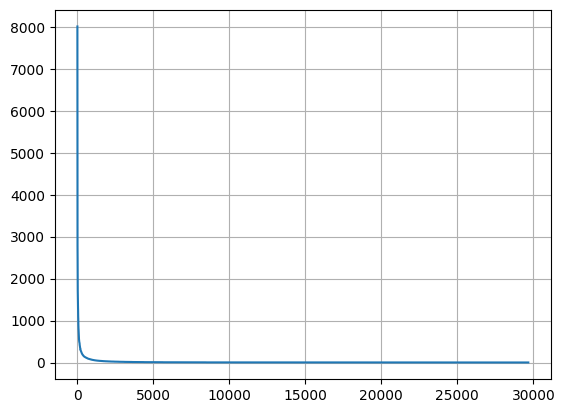

In [ ]:
col = 'model'
counts = df[col].fillna('others').value_counts()
plt.grid()
plt.plot(range(len(counts)), counts)

In [ ]:
n_categorical = 10
others = counts.index[n_categorical:]
df[col] = df[col].apply(lambda s : s if str(s) not in others else 'others')
df[col].value_counts()

,count
model,
others,386690
f-150,8009
silverado 1500,5140
1500,4211
camry,3135
silverado,3023
accord,2969
wrangler,2848
civic,2799


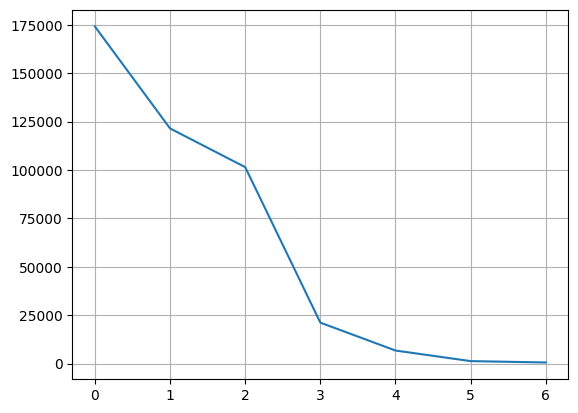

In [ ]:
col = 'condition'
counts = df[col].fillna('others').value_counts()
plt.grid()
plt.plot(range(len(counts)), counts)

In [ ]:
n_categorical = 3
df[col] = df[col].apply(lambda s : s if str(s) not in counts.index[n_categorical:] else 'others')
df[col].value_counts()

,count
condition,
good,121456
excellent,101467
others,29853


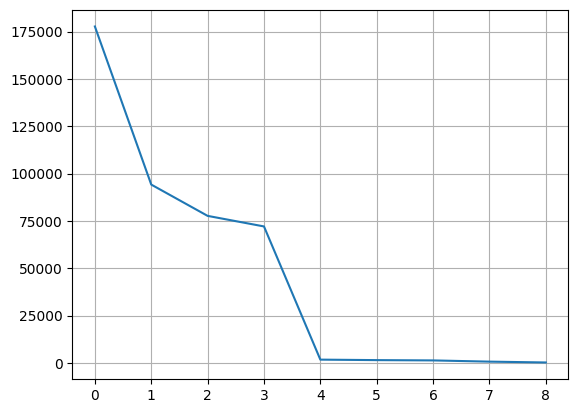

In [ ]:
col = 'cylinders'
counts = df[col].fillna('others').value_counts()
plt.grid()
plt.plot(range(len(counts)), counts)

In [ ]:
n_categorical = 4
df[col] = df[col].apply(lambda s : s if str(s) not in counts.index[n_categorical:] else 'others')
df[col].value_counts()

,count
cylinders,
6 cylinders,94169
4 cylinders,77642
8 cylinders,72062
others,5329


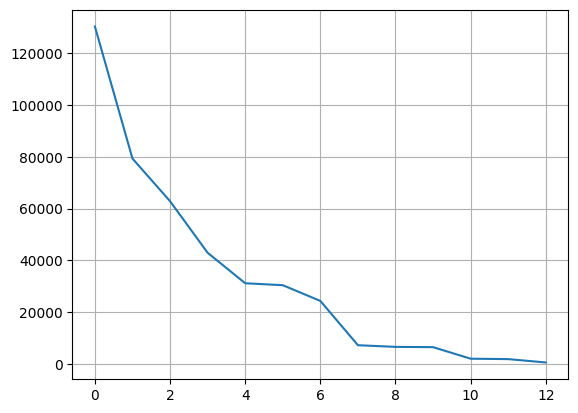

In [ ]:
col = 'paint_color'
counts = df[col].fillna('others').value_counts()
plt.grid()
plt.plot(range(len(counts)), counts)

In [ ]:
n_categorical = 7
others = counts.index[n_categorical:]
df[col] = df[col].apply(lambda s : s if str(s) not in others else 'others')
df[col].value_counts()

,count
paint_color,
white,79285
black,62861
silver,42970
blue,31223
red,30473
others,25449
grey,24416


In [ ]:
df.loc[df[col] == 'other', col] = 'others'

In [ ]:
df.drop('title_status', axis = 1, inplace = True)

### 문제 9. 수치형 데이터 시각화하여 분석하기

<Axes: xlabel='price'>

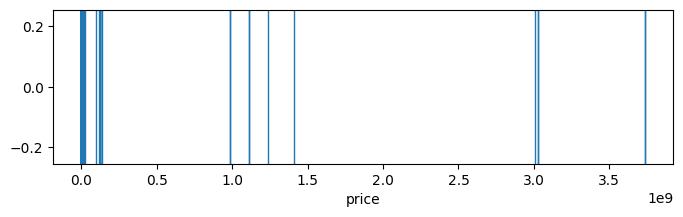

In [ ]:
# Seaborn을 이용하여 범주형 데이터를 시각화하여 분석하기
# Hint) 값의 범위가 너무 넓을 경우 histplot() 등이 잘 동작하지 않으므로, rugplot을 활용
fig = plt.figure(figsize = (8,2))
sns.rugplot(x = 'price', data = df, height = 1)


<Axes: xlabel='odometer'>

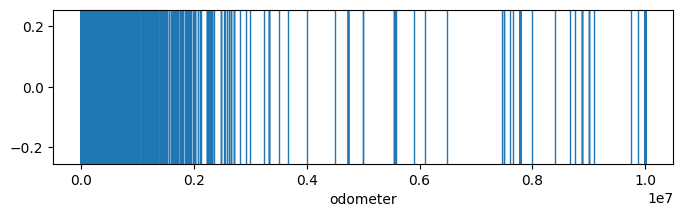

In [ ]:
fig = plt.figure(figsize = (8,2))
sns.rugplot(x = 'odometer', data = df, height = 1)

### 문제 10. 수치형 데이터 클리닝하기

In [ ]:
# quantile() 메소드를 이용하여 outlier 제거하고 시각화하여 확인하기

p1 = df['price'].quantile(0.99)
p2 = df['price'].quantile(0.1)
print(p1, p2)


66995.0 500.0


In [ ]:
df = df[(df['price'] < p1) & (df['price'] > p2)]

In [ ]:
o1 = df['odometer'].quantile(0.99)
o2 = df['odometer'].quantile(0.1)
print(o1, o2)

280000.0 14939.0


In [ ]:
df = df[(df['odometer'] < o1) & (df['odometer'] > o2)]

In [ ]:
df.describe()

,price,odometer,county,age
count,338073.000000,338073.000000,0.0,337457.000000
mean,17618.115265,100771.015355,NaN,15.204921
std,12678.374523,57120.746792,NaN,8.489158
min,501.000000,14940.000000,NaN,4.000000
25%,7495.000000,51933.000000,NaN,10.000000
50%,14599.000000,96281.000000,NaN,13.000000
75%,25590.000000,140000.000000,NaN,18.000000
max,66992.000000,279974.000000,NaN,126.000000


<Axes: xlabel='manufacturer', ylabel='price'>

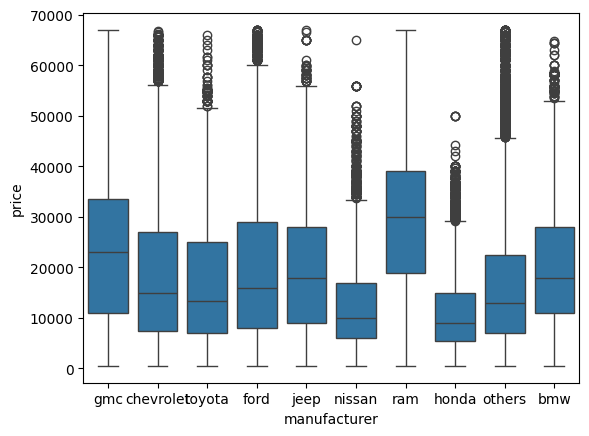

In [ ]:
sns.boxplot(x = 'manufacturer', y = 'price', data = df)

<Axes: xlabel='model', ylabel='price'>

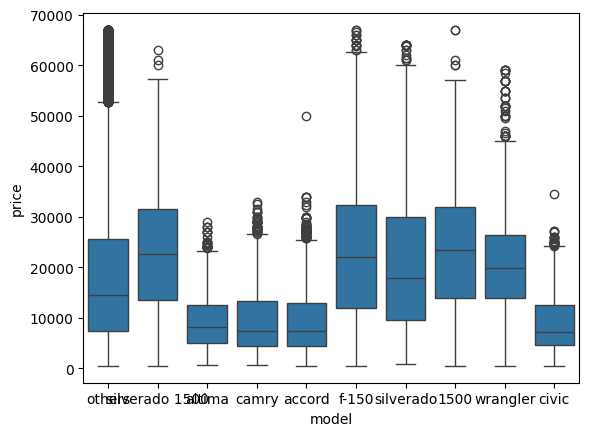

In [ ]:
sns.boxplot(x = 'model', y = 'price', data = df)

### 문제 11. 컬럼간의 Correlation Heatmap으로 시각화하기

<Axes: >

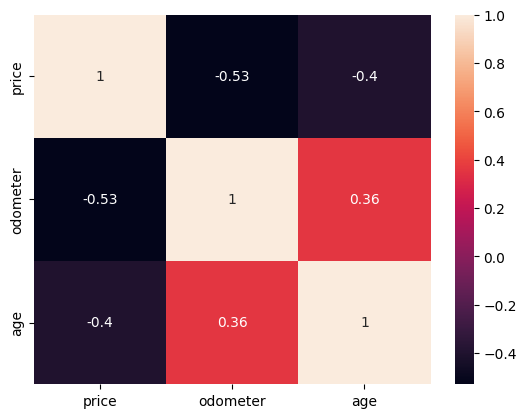

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot = True)



## Step 4. 모델 학습을 위한 데이터 전처리

### 문제 12. StandardScaler를 이용해 수치형 데이터 표준화하기


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# StandardScaler를 이용해 수치형 데이터를 표준화하기
X_num = df[['odometer', 'age']]

scaler = StandardScaler()
scaler.fit(X_num)
X_scaled = scaler.transform(X_num)
X_scaled = pd.DataFrame(X_scaled, index = X_num.index, columns = X_num.columns)
# get_dummies를 이용해 범주형 데이터를 one-hot 벡터로 변경하기
X_cat = df.drop(['price', 'odometer', 'age'], axis = 1)
X_cat = pd.get_dummies(X_cat)

# 입출력 데이터 통합하기
X = pd.concat([X_scaled, X_cat], axis = 1)
y = df['price']

In [ ]:
X.head()

,odometer,age,region_columbus,region_eugene,region_fresno / madera,region_jacksonville,region_others,region_spokane / coeur d'alene,manufacturer_bmw,manufacturer_chevrolet,...,type_pickup,type_sedan,type_truck,paint_color_black,paint_color_blue,paint_color_grey,paint_color_others,paint_color_red,paint_color_silver,paint_color_white
27,-0.750132,-0.377532,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
28,-0.517186,0.093658,False,False,False,False,True,False,False,True,...,True,False,False,False,True,False,False,False,False,False
29,-1.428748,-1.084317,False,False,False,False,True,False,False,True,...,True,False,False,False,False,False,False,True,False,False
30,-1.044228,-0.730924,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
31,0.476692,-0.259734,False,False,False,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,False


In [ ]:
X.isna().sum()

,0
odometer,0
age,616
region_columbus,0
region_eugene,0
region_fresno / madera,0
region_jacksonville,0
region_others,0
region_spokane / coeur d'alene,0
manufacturer_bmw,0
manufacturer_chevrolet,0


In [ ]:
X.fillna(0.0, inplace = True)

### 문제 13. 학습데이터와 테스트데이터 분리하기


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# train_test_split() 함수로 학습 데이터와 테스트 데이터 분리하기
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 1)

## Step 5. Regression 모델 학습하기

### 문제 14. XGBoost Regression 모델 학습하기

In [ ]:
from xgboost import XGBRegressor

In [ ]:
# XGBRegressor 모델 생성/학습
model_reg = XGBRegressor()
model_reg.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### 문제 15. 모델 학습 결과 평가하기

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

In [ ]:
# Predict를 수행하고 mean_absolute_error, rmse 결과 출력하기
pred = model_reg.predict(X_test)
print(mean_absolute_error(y_test, pred))
print(sqrt(mean_squared_error(y_test, pred)))



3786.616455078125
5779.184198483381


## Step 6. 모델 학습 결과 심화 분석하기


### 문제 16. 실제 값과 추측 값의 Scatter plot 시각화하기


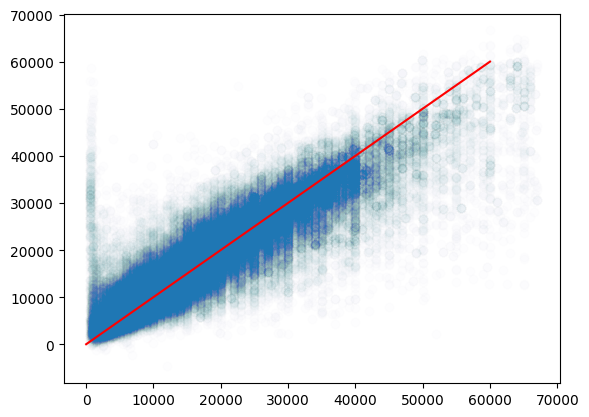

In [ ]:
# y_test vs. pred Scatter 플랏으로 시각적으로 분석하기
# Hint) Scatter로 시각적 확인이 어려울 경우, histplot 등 활용
plt.scatter(x = y_test, y = pred, alpha = 0.006)
plt.plot([0,60000], [0,60000], '-r')


### 문제 17. 에러 값의 히스토그램 확인하기


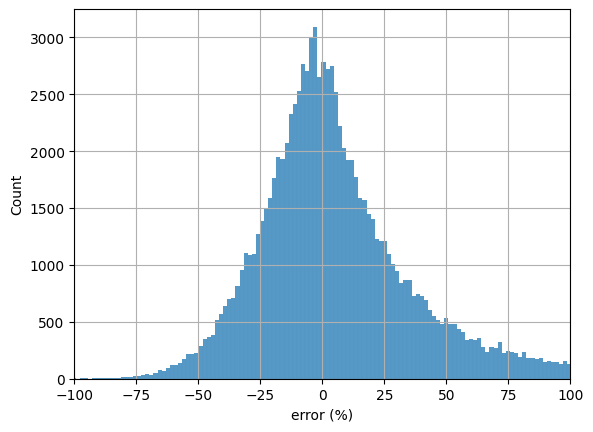

In [ ]:
# err의 히스토그램으로 에러율 히스토그램 확인하기
err = (pred - y_test) / y_test * 100
sns.histplot(err)
plt.xlabel('error (%)')
plt.xlim(-100, 100)
plt.grid()



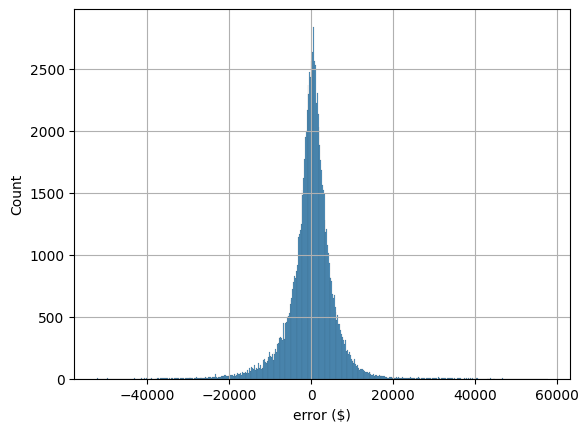

In [ ]:
err = (pred - y_test)
sns.histplot(err)
plt.xlabel('error ($)')
plt.grid()